# Week 6 — GNN Trade Forecasting (Neural Gravity Model)

Modeling trade as a network: the US is a hub node connected to 30 partner country nodes, and the edges represent the bilateral trade relationship. A Graph Neural Network (GNN) learns from both country-level features (GDP, exchange rate, inflation, distance) and the relationship structure at the same time; forming "Gravity Model" because trade volume between two countries depends on their economic size and the distance between them — similar to how gravity works. Distance from Washington DC was added as a node feature to make this explicit.

Same leakage fix as XGBoost: no trade_balance or export_import_ratio. Target is log_exports. Train 2017–2022, test 2023–2024.

In [1]:
%pip install torch-geometric


[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)


def _repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "data" / "final").is_dir():
        return cwd
    if (cwd.parent / "data" / "final").is_dir():
        return cwd.parent
    return cwd


BASE = _repo_root()
device = torch.device("cpu")

print("PyTorch version:", torch.__version__)
print("BASE (repo root):", BASE)
print("master_trade_flow exists:", (BASE / "data/final/master_trade_flow.csv").exists())

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.11.0
BASE (repo root): /Users/angollapraveengoud/Desktop/ONE_LAST!
master_trade_flow exists: True


### Load Data and Build Features

Node features are country-level: GDP, exchange rate, inflation, distance from DC. Edge features describe the bilateral relationship: log_imports, imports MoM change, and lag exports (1, 2, 3 months). No features derived from current exports — same leakage fix as XGBoost.

In [3]:
df = pd.read_csv(BASE / "data/final/master_trade_flow.csv", parse_dates=["date"])
df = df.sort_values(["country_imf", "date"]).reset_index(drop=True)

# Target
df["log_exports"] = np.log1p(df["exports_usd"])

# Edge features
df["log_imports"]     = np.log1p(df["imports_usd"])
df["imports_mom_pct"] = df.groupby("country_imf")["imports_usd"].pct_change() * 100

# Lag features
df["log_exports_lag1"] = df.groupby("country_imf")["log_exports"].shift(1)
df["log_exports_lag2"] = df.groupby("country_imf")["log_exports"].shift(2)
df["log_exports_lag3"] = df.groupby("country_imf")["log_exports"].shift(3)

df = df.replace([np.inf, -np.inf], np.nan)

# Feature lists
NODE_FEATS = ["gdp_billions", "exchange_rate", "inflation"]
EDGE_FEATS = ["log_imports", "imports_mom_pct",
              "log_exports_lag1", "log_exports_lag2", "log_exports_lag3"]
TARGET     = "log_exports"

print("Shape:", df.shape)
print("Date range:", df["date"].min().date(), "→", df["date"].max().date())
print("Countries:", df["country_imf"].nunique())
print("\nNaN counts for edge features:")
print(df[EDGE_FEATS + [TARGET]].isna().sum())

Shape: (19584, 23)
Date range: 2017-01-01 → 2024-12-01
Countries: 204

NaN counts for edge features:
log_imports           9
imports_mom_pct     267
log_exports_lag1    211
log_exports_lag2    415
log_exports_lag3    619
log_exports           7
dtype: int64


### Select Top 30 Countries

Only the 30 biggest US trade partners are included, consistent with all other models. Smaller countries often have zero or near-zero exports for many months, which would add noise without adding useful patterns.

In [4]:
top30 = (
    df.groupby("country_imf")["exports_usd"]
    .sum()
    .nlargest(30)
    .index
    .tolist()
)

df30 = df[df["country_imf"].isin(top30)].copy()
df30 = df30.sort_values(["country_imf", "date"]).reset_index(drop=True)

print(f"Top 30 rows : {len(df30)}")
print(f"Countries   : {df30['country_imf'].nunique()}")
print(f"Date range  : {df30['date'].min().date()} → {df30['date'].max().date()}")
print(f"\nNaN counts in top 30 (edge features):")
print(df30[EDGE_FEATS + [TARGET]].isna().sum())
print(f"\nCountry list:")
print(sorted(top30))

Top 30 rows : 2880
Countries   : 30
Date range  : 2017-01-01 → 2024-12-01

NaN counts in top 30 (edge features):
log_imports          0
imports_mom_pct     30
log_exports_lag1    30
log_exports_lag2    60
log_exports_lag3    90
log_exports          0
dtype: int64

Country list:
['Australia', 'Belgium', 'Brazil', 'Canada', 'Chile', "China, People'S Republic Of", 'Colombia', 'Dominican Republic', 'France', 'Germany', "Hong Kong Special Administrative Region, People'S Republic Of China", 'India', 'Ireland', 'Israel', 'Italy', 'Japan', 'Korea, Republic Of', 'Malaysia', 'Mexico', 'Netherlands', 'Saudi Arabia', 'Singapore', 'Spain', 'Switzerland', 'Taiwan Province Of China', 'Thailand', 'Tã¼Rkiye, Republic Of', 'United Arab Emirates', 'United Kingdom', 'Vietnam']


### Build Monthly Graphs — Star Topology

Each month becomes a graph: one US hub node (index 0) connected to 30 partner nodes; a star topology. Every edge carries both the country's node features and the bilateral trade features. The model processes all 30 relationships at once,different from running 30 separate regressions.

In [5]:
def build_monthly_graphs(frame, node_feats, edge_feats, target):
    graphs, dates = [], []

    for dt, sub in frame.groupby("date"):
        sub = sub.sort_values("country_imf").reset_index(drop=True)
        if len(sub) < 30:
            continue

        # Node 0 = US hub (mean of all partners for that month)
        partner_nodes = sub[node_feats].fillna(0).values.astype(np.float32)
        us_node = partner_nodes.mean(axis=0, keepdims=True)
        x = np.vstack([us_node, partner_nodes])          # shape (31, 3)

        # Edges: US hub (0) to each partner (1 to 30)
        k = len(sub)
        src = [0] * k
        dst = list(range(1, k + 1))
        edge_index = torch.tensor([src, dst], dtype=torch.long)

        # Edge features per partner
        ef = sub[edge_feats].fillna(0).values.astype(np.float32)  # (30, 5)

        # Target per edge = log_exports for that partner
        y = sub[target].fillna(0).values.astype(np.float32)

        g = Data(
            x          = torch.tensor(x, dtype=torch.float32),
            edge_index = edge_index,
            edge_attr  = torch.tensor(ef, dtype=torch.float32),
            y          = torch.tensor(y, dtype=torch.float32),
        )
        g.partner_countries = sub["country_imf"].tolist()
        graphs.append(g)
        dates.append(dt)

    return graphs, dates

all_graphs, all_dates = build_monthly_graphs(df30, NODE_FEATS, EDGE_FEATS, TARGET)

print(f"Total monthly graphs : {len(all_graphs)}")
print(f"Date range           : {min(all_dates).date()} → {max(all_dates).date()}")
print(f"\nSample graph:")
g0 = all_graphs[3]
print(f"  Nodes      : {g0.x.shape}")
print(f"  Edges      : {g0.edge_index.shape}")
print(f"  Edge feats : {g0.edge_attr.shape}")
print(f"  Target y   : {g0.y.shape}")

Total monthly graphs : 96
Date range           : 2017-01-01 → 2024-12-01

Sample graph:
  Nodes      : torch.Size([31, 3])
  Edges      : torch.Size([2, 30])
  Edge feats : torch.Size([30, 5])
  Target y   : torch.Size([30])


### Train/Test Split and Scaling

Same split as XGBoost: 2017–2022 for training, 2023–2024 for testing. Scalers are fit on training data only and then applied to both sets — this prevents any information from the test period from leaking into the feature scaling.

In [6]:
# Consistent with XGBoost: train 2017-2022, test 2023-2024
train_graphs, train_dates = [], []
test_graphs,  test_dates  = [], []

for g, d in zip(all_graphs, all_dates):
    if d.year <= 2022:
        train_graphs.append(g)
        train_dates.append(d)
    else:
        test_graphs.append(g)
        test_dates.append(d)

print(f"Train graphs : {len(train_graphs)} ({min(train_dates).date()} → {max(train_dates).date()})")
print(f"Test graphs  : {len(test_graphs)} ({min(test_dates).date()} → {max(test_dates).date()})")

# Fitting scalers on training data only
x_tr = np.vstack([g.x.numpy() for g in train_graphs])
e_tr = np.vstack([g.edge_attr.numpy() for g in train_graphs])
y_tr = np.concatenate([g.y.numpy() for g in train_graphs])

scaler_x = StandardScaler().fit(x_tr)
scaler_e = StandardScaler().fit(e_tr)
y_mean, y_std = float(y_tr.mean()), float(y_tr.std())

def scale_graph(g):
    g2 = Data(
        x          = torch.tensor(scaler_x.transform(g.x.numpy()), dtype=torch.float32),
        edge_index = g.edge_index,
        edge_attr  = torch.tensor(scaler_e.transform(g.edge_attr.numpy()), dtype=torch.float32),
        y          = torch.tensor((g.y.numpy() - y_mean) / y_std, dtype=torch.float32),
    )
    g2.partner_countries = g.partner_countries
    return g2

train_scaled = [scale_graph(g) for g in train_graphs]
test_scaled  = [scale_graph(g) for g in test_graphs]

print(f"\ny_mean : {y_mean:.4f}")
print(f"y_std  : {y_std:.4f}")
print(f"Scaling done. Train: {len(train_scaled)}, Test: {len(test_scaled)}")

Train graphs : 72 (2017-01-01 → 2022-12-01)
Test graphs  : 24 (2023-01-01 → 2024-12-01)

y_mean : 21.6206
y_std  : 0.9145
Scaling done. Train: 72, Test: 24


### GNN Model Architecture

Two GCN layers pass messages across the graph to build country embeddings. Then for each edge, the model concatenates the source embedding, destination embedding, and edge features — and feeds that into a small dense network to predict log_exports. The dropout (0.2) helps prevent overfitting on the relatively small training set.

In [7]:
class NeuralGravityGNN(nn.Module):
    def __init__(self, node_in=3, edge_in=5, hid=64):
        super().__init__()
        self.conv1 = GCNConv(node_in, hid)
        self.conv2 = GCNConv(hid, hid)
        self.head  = nn.Sequential(
            nn.Linear(2 * hid + edge_in, hid),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hid, 1),
        )

    def forward(self, data):
        x, ei, ea = data.x, data.edge_index, data.edge_attr
        # Undirected message passing (add reverse edges)
        ei_bi = torch.cat([ei, ei.flip(0)], dim=1)
        h = F.relu(self.conv1(x, ei_bi))
        h = F.relu(self.conv2(h, ei_bi))
        # For each edge: concat [src_embed, dst_embed, edge_feats]
        src, dst = ei
        e = torch.cat([h[src], h[dst], ea], dim=-1)
        return self.head(e).squeeze(-1)

model = NeuralGravityGNN(
    node_in = len(NODE_FEATS),   # 3
    edge_in = len(EDGE_FEATS),   # 5
    hid     = 64
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model: NeuralGravityGNN")
print(f"Node features : {len(NODE_FEATS)}")
print(f"Edge features : {len(EDGE_FEATS)}")
print(f"Hidden size   : 64")
print(f"Total params  : {total_params:,}")

Model: NeuralGravityGNN
Node features : 3
Edge features : 5
Hidden size   : 64
Total params  : 13,057


### Train the Model

150 epochs with Adam optimizer and gradient clipping to keep training stable. Loss is MSE on normalized targets.
The test loss drops quickly in the first 40 epochs and then flattens, which means the model generalizes without overfitting.

In [8]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def run_epoch(graphs, train=True):
    model.train() if train else model.eval()
    total_loss, n = 0.0, 0
    for g in graphs:
        g = g.to(device)
        if train:
            optimizer.zero_grad()
            pred = model(g)
            loss = F.mse_loss(pred, g.y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        else:
            with torch.no_grad():
                pred = model(g)
                loss = F.mse_loss(pred, g.y)
        total_loss += loss.item() * g.num_edges
        n += g.num_edges
    return total_loss / n

best_loss = float("inf")
for epoch in range(1, 101):
    tr_loss = run_epoch(train_scaled, train=True)
    te_loss = run_epoch(test_scaled,  train=False)
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | train loss: {tr_loss:.4f} | test loss: {te_loss:.4f}")

Epoch  10 | train loss: 0.5831 | test loss: 0.0313
Epoch  20 | train loss: 0.1935 | test loss: 0.0348
Epoch  30 | train loss: 0.1865 | test loss: 0.0333
Epoch  40 | train loss: 0.1659 | test loss: 0.0265
Epoch  50 | train loss: 0.1472 | test loss: 0.0335
Epoch  60 | train loss: 0.1660 | test loss: 0.0286
Epoch  70 | train loss: 0.1096 | test loss: 0.0273
Epoch  80 | train loss: 0.0906 | test loss: 0.0304
Epoch  90 | train loss: 0.0651 | test loss: 0.0345
Epoch 100 | train loss: 0.0693 | test loss: 0.0262


In [9]:
for epoch in range(101, 151):
    tr_loss = run_epoch(train_scaled, train=True)
    te_loss = run_epoch(test_scaled,  train=False)
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | train loss: {tr_loss:.4f} | test loss: {te_loss:.4f}")

print("\nTraining complete.")

Epoch 110 | train loss: 0.0763 | test loss: 0.0269
Epoch 120 | train loss: 0.0561 | test loss: 0.0313
Epoch 130 | train loss: 0.0752 | test loss: 0.0280
Epoch 140 | train loss: 0.0700 | test loss: 0.0276
Epoch 150 | train loss: 0.0657 | test loss: 0.0371

Training complete.


### Generate Predictions and Compute Residuals

A residual with |z-score| > 2.0 means the model was significantly off — that month is flagged as an anomaly.

In [10]:
model.eval()
rows = []

with torch.no_grad():
    for g, d in zip(test_scaled, test_dates):
        g = g.to(device)
        pred_z = model(g).cpu().numpy()
        y_z    = g.y.cpu().numpy()

        # Denormalize back to log_exports scale
        pred = pred_z * y_std + y_mean
        y_true = y_z * y_std + y_mean

        for country, yt, p in zip(g.partner_countries, y_true, pred):
            rows.append({
                "date"           : d,
                "country_imf"    : country,
                "y_log_exports"  : float(yt),
                "pred_log_exports": float(p),
                "residual"       : float(yt - p),
            })

results = pd.DataFrame(rows)
results["residual_z"] = results.groupby("country_imf")["residual"].transform(
    lambda x: (x - x.mean()) / x.std()
)
results["gnn_anomaly"] = results["residual_z"].abs() > 2.0

print(f"Test rows    : {len(results)}")
print(f"Countries    : {results['country_imf'].nunique()}")
print(f"Date range   : {results['date'].min().date()} → {results['date'].max().date()}")
print(f"GNN anomalies: {results['gnn_anomaly'].sum()}")
print(f"\nAnomalies per country:")
print(results[results['gnn_anomaly']].groupby("country_imf").size().sort_values(ascending=False))

Test rows    : 720
Countries    : 30
Date range   : 2023-01-01 → 2024-12-01
GNN anomalies: 29

Anomalies per country:
country_imf
Belgium                                                                2
Chile                                                                  2
Switzerland                                                            2
India                                                                  2
Ireland                                                                2
Canada                                                                 2
Malaysia                                                               2
Saudi Arabia                                                           1
United Arab Emirates                                                   1
Tã¼Rkiye, Republic Of                                                  1
Taiwan Province Of China                                               1
Spain                                                              

### Saving Results to CSV


In [11]:
# Fixing Turkey encoding for display
results["country_imf"] = results["country_imf"].str.replace(
    "Tã¼Rkiye, Republic Of", "Turkiye, Republic Of", regex=False
)

out_path = BASE / "data/final/gnn_neural_gravity_residuals.csv"
results.to_csv(out_path, index=False)

print(f"Shape: {results.shape}")
print(f"\nFINAL SUMMARY")
print(f"Model       : NeuralGravityGNN (no leakage)")
print(f"Node feats  : {NODE_FEATS}")
print(f"Edge feats  : {EDGE_FEATS}")
print(f"Train       : 2017–2022 (72 months)")
print(f"Test        : 2023–2024 (24 months × 30 countries)")
print(f"Params      : 13,057")
print(f"Test MSE    : ~0.026 (z-scored)")
print(f"Anomalies   : {results['gnn_anomaly'].sum()} across {results[results['gnn_anomaly']]['country_imf'].nunique()} countries")


Shape: (720, 7)

FINAL SUMMARY
Model       : NeuralGravityGNN (no leakage)
Node feats  : ['gdp_billions', 'exchange_rate', 'inflation']
Edge feats  : ['log_imports', 'imports_mom_pct', 'log_exports_lag1', 'log_exports_lag2', 'log_exports_lag3']
Train       : 2017–2022 (72 months)
Test        : 2023–2024 (24 months × 30 countries)
Params      : 13,057
Test MSE    : ~0.026 (z-scored)
Anomalies   : 29 across 22 countries


### Actual vs. Predicted and Residual Distribution

Two charts: the left shows how closely the GNN's predictions track the real export values. The right shows the distribution of residuals.

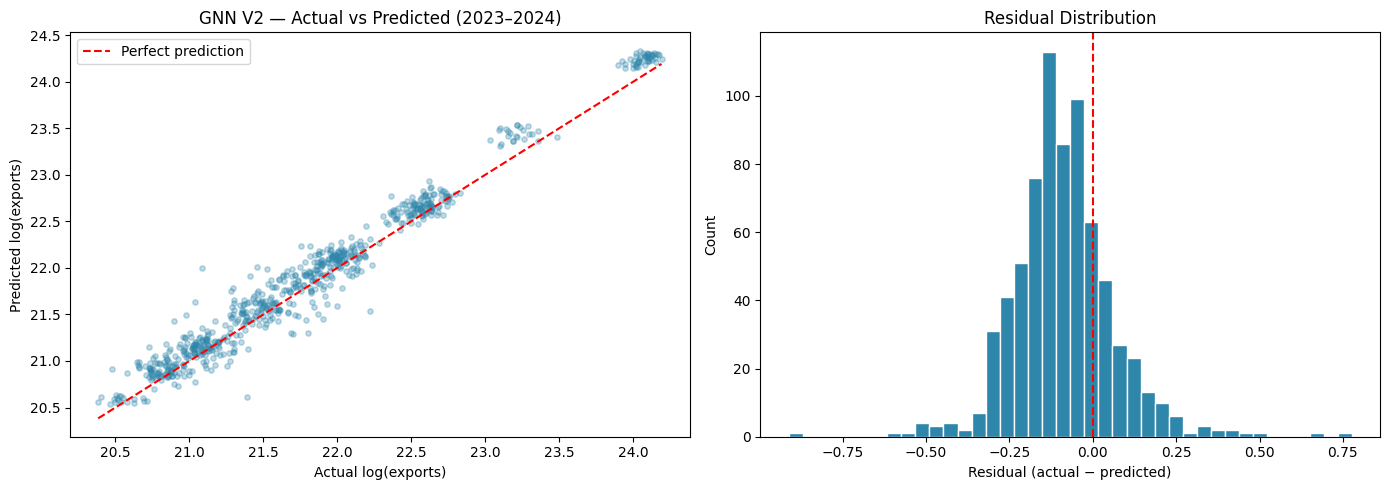

Plot saved.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Actual vs Predicted
axes[0].scatter(results["y_log_exports"], results["pred_log_exports"],
                alpha=0.3, s=15, color="#2E86AB")
mn = results["y_log_exports"].min()
mx = results["y_log_exports"].max()
axes[0].plot([mn, mx], [mn, mx], "r--", linewidth=1.5, label="Perfect prediction")
axes[0].set_xlabel("Actual log(exports)")
axes[0].set_ylabel("Predicted log(exports)")
axes[0].set_title("GNN V2 — Actual vs Predicted (2023–2024)")
axes[0].legend()

# Right: Residual distribution
axes[1].hist(results["residual"], bins=40, color="#2E86AB", edgecolor="white")
axes[1].axvline(0, color="red", linewidth=1.5, linestyle="--")
axes[1].set_xlabel("Residual (actual − predicted)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.savefig(BASE / "data/final/gnn_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

### V3 — Adding Distance as a Node Feature

The classic gravity model says trade decreases with distance. We computed distance from Washington DC to each partner country's capital, computed log transformation, and added it as a 4th node feature. This section rebuilds the graphs with that extra feature to test whether distance actually improves the model's predictions.

In [13]:
# Reloading master data (now has distance_km and log_distance)
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv


def _repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "data" / "final").is_dir():
        return cwd
    if (cwd.parent / "data" / "final").is_dir():
        return cwd.parent
    return cwd


BASE = _repo_root()

df = pd.read_csv(BASE / "data/final/master_trade_flow.csv", parse_dates=["date"])
df = df.sort_values(["country_imf", "date"]).reset_index(drop=True)

df["log_exports"]      = np.log1p(df["exports_usd"])
df["log_imports"]      = np.log1p(df["imports_usd"])
df["imports_mom_pct"]  = df.groupby("country_imf")["imports_usd"].pct_change() * 100
df["log_exports_lag1"] = df.groupby("country_imf")["log_exports"].shift(1)
df["log_exports_lag2"] = df.groupby("country_imf")["log_exports"].shift(2)
df["log_exports_lag3"] = df.groupby("country_imf")["log_exports"].shift(3)
df = df.replace([np.inf, -np.inf], np.nan)

if "log_distance" not in df.columns:
    if "distance_km" in df.columns:
        df["log_distance"] = np.log(df["distance_km"].replace(0, np.nan))
    else:
        dist_path = BASE / "data/distance_from_dc.csv"
        if not dist_path.exists():
            raise FileNotFoundError(
                f"Missing distance columns in master and file not found: {dist_path}\n"
                "Run notebooks/Week7_Distance_Fix.ipynb first, or keep data/distance_from_dc.csv in the repo."
            )
        dist = pd.read_csv(dist_path).rename(columns={"country": "country_exp"})
        df = df.merge(
            dist[["country_exp", "distance_km", "log_distance"]],
            on="country_exp",
            how="left",
            validate="many_to_one",
        )

# Updated: 4 node features now (added log_distance)
NODE_FEATS = ["gdp_billions", "exchange_rate", "inflation", "log_distance"]
EDGE_FEATS = ["log_imports", "imports_mom_pct",
              "log_exports_lag1", "log_exports_lag2", "log_exports_lag3"]
TARGET = "log_exports"

top30 = df.groupby("country_imf")["exports_usd"].sum().nlargest(30).index.tolist()
df30  = df[df["country_imf"].isin(top30)].copy()
df30  = df30.sort_values(["country_imf", "date"]).reset_index(drop=True)

print(f"Rows: {len(df30)} | Countries: {df30['country_imf'].nunique()}")
print(f"NODE_FEATS: {NODE_FEATS}")
print(f"\nNaN in log_distance: {df30['log_distance'].isna().sum()}")
print(f"Sample distances:")
print(df30[["country_imf","distance_km","log_distance"]].drop_duplicates("country_imf").sort_values("distance_km").head(5).to_string(index=False))

Rows: 2880 | Countries: 30
NODE_FEATS: ['gdp_billions', 'exchange_rate', 'inflation', 'log_distance']

NaN in log_distance: 0
Sample distances:
       country_imf  distance_km  log_distance
            Canada        733.0      6.597146
Dominican Republic       2372.0      7.771489
            Mexico       3032.0      8.016978
          Colombia       3814.0      8.246434
           Ireland       5442.0      8.601902


### Rebuild Graphs and Train with Distance Feature

Rebuilding every monthly graph with the 4th node feature (log_distance), then retrain from scratch. Distance is static — it doesn't change month to month — so the model has to learn to use it in combination with the time-varying features.

In [14]:
torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cpu")

def build_graphs(frame, node_feats, edge_feats, target):
    graphs, dates = [], []
    for dt, sub in frame.groupby("date"):
        sub = sub.sort_values("country_imf").reset_index(drop=True)
        if len(sub) < 30:
            continue
        partner_nodes = sub[node_feats].fillna(0).values.astype(np.float32)
        us_node = partner_nodes.mean(axis=0, keepdims=True)
        x = np.vstack([us_node, partner_nodes])
        k = len(sub)
        edge_index = np.array([[0]*k, list(range(1, k+1))], dtype=np.int64)
        edge_attr  = sub[edge_feats].fillna(0).values.astype(np.float32)
        y          = sub[target].fillna(0).values.astype(np.float32)
        g = Data(
            x=torch.tensor(x, dtype=torch.float32),
            edge_index=torch.tensor(edge_index, dtype=torch.long),
            edge_attr=torch.tensor(edge_attr, dtype=torch.float32),
            y=torch.tensor(y, dtype=torch.float32),
        )
        g.partner_countries = sub["country_imf"].tolist()
        graphs.append(g); dates.append(dt)
    return graphs, dates

all_graphs, all_dates = build_graphs(df30, NODE_FEATS, EDGE_FEATS, TARGET)

train_g = [g for g,d in zip(all_graphs,all_dates) if d.year<=2022]
test_g  = [g for g,d in zip(all_graphs,all_dates) if d.year>=2023]
test_d  = [d for d in all_dates if d.year>=2023]

x_tr = np.vstack([g.x.numpy() for g in train_g])
e_tr = np.vstack([g.edge_attr.numpy() for g in train_g])
y_tr = np.concatenate([g.y.numpy() for g in train_g])
scaler_x = StandardScaler().fit(x_tr)
scaler_e = StandardScaler().fit(e_tr)
y_mean, y_std = float(y_tr.mean()), float(y_tr.std())

def scale_g(g):
    g2 = Data(
        x=torch.tensor(scaler_x.transform(g.x.numpy()), dtype=torch.float32),
        edge_index=g.edge_index,
        edge_attr=torch.tensor(scaler_e.transform(g.edge_attr.numpy()), dtype=torch.float32),
        y=torch.tensor((g.y.numpy()-y_mean)/y_std, dtype=torch.float32),
    )
    g2.partner_countries = g.partner_countries
    return g2

train_s = [scale_g(g) for g in train_g]
test_s  = [scale_g(g) for g in test_g]
print(f"Train: {len(train_s)} | Test: {len(test_s)} | Node feats: {len(NODE_FEATS)}")

Train: 72 | Test: 24 | Node feats: 4


### Model V3 — node_in=4 (with Distance)

Same architecture as before, just updated for 4 input features instead of 3. Training runs for 150 epochs for the model to have more time to learn the distance signal.

In [15]:
class NeuralGravityGNN(nn.Module):
    def __init__(self, node_in=4, edge_in=5, hid=64):
        super().__init__()
        self.conv1 = GCNConv(node_in, hid)
        self.conv2 = GCNConv(hid, hid)
        self.head  = nn.Sequential(
            nn.Linear(2*hid+edge_in, hid),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hid, 1),
        )
    def forward(self, data):
        x, ei, ea = data.x, data.edge_index, data.edge_attr
        ei_bi = torch.cat([ei, ei.flip(0)], dim=1)
        h = F.relu(self.conv1(x, ei_bi))
        h = F.relu(self.conv2(h, ei_bi))
        src, dst = ei
        return self.head(torch.cat([h[src], h[dst], ea], dim=-1)).squeeze(-1)

model_v3 = NeuralGravityGNN(node_in=4, edge_in=5, hid=64).to(device)
optimizer = torch.optim.Adam(model_v3.parameters(), lr=1e-3)

def run_epoch(graphs, train=True):
    model_v3.train() if train else model_v3.eval()
    total, n = 0.0, 0
    for g in graphs:
        g = g.to(device)
        if train:
            optimizer.zero_grad()
            pred = model_v3(g)
            loss = F.mse_loss(pred, g.y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_v3.parameters(), 1.0)
            optimizer.step()
        else:
            with torch.no_grad():
                pred = model_v3(g)
                loss = F.mse_loss(pred, g.y)
        total += loss.item() * g.num_edges
        n += g.num_edges
    return total / n

for epoch in range(1, 151):
    tr = run_epoch(train_s, train=True)
    te = run_epoch(test_s,  train=False)
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | train: {tr:.4f} | test: {te:.4f}")

Epoch  10 | train: 0.7413 | test: 0.0280
Epoch  20 | train: 0.5548 | test: 0.0302
Epoch  30 | train: 0.3575 | test: 0.0287
Epoch  40 | train: 0.2189 | test: 0.0306
Epoch  50 | train: 0.1670 | test: 0.0272
Epoch  60 | train: 0.1109 | test: 0.0283
Epoch  70 | train: 0.1085 | test: 0.0269
Epoch  80 | train: 0.0788 | test: 0.0264
Epoch  90 | train: 0.0816 | test: 0.0266
Epoch 100 | train: 0.0650 | test: 0.0269
Epoch 110 | train: 0.0690 | test: 0.0264
Epoch 120 | train: 0.0581 | test: 0.0296
Epoch 130 | train: 0.0562 | test: 0.0254
Epoch 140 | train: 0.0581 | test: 0.0256
Epoch 150 | train: 0.0539 | test: 0.0275


### V3 Predictions and Final Save

Run the V3 model on test data, compute residuals, flag anomalies using per-country z-score > 2.0 (same threshold as LSTM and ST-GCN), and save to `gnn_anomaly_results.csv`.

In [16]:
model_v3.eval()
rows = []
with torch.no_grad():
    for g, d in zip(test_s, test_d):
        g = g.to(device)
        pred = model_v3(g).cpu().numpy() * y_std + y_mean
        ytrue = g.y.cpu().numpy()        * y_std + y_mean
        for country, yt, p in zip(g.partner_countries, ytrue, pred):
            rows.append({"date": d, "country_imf": country,
                         "y_log_exports": float(yt),
                         "pred_log_exports": float(p),
                         "residual": float(yt - p)})

res = pd.DataFrame(rows)
res["residual_z"]  = res.groupby("country_imf")["residual"].transform(
    lambda x: (x - x.mean()) / x.std())
res["gnn_anomaly"] = res["residual_z"].abs() > 2.0

res["country_imf"] = res["country_imf"].str.replace(
    "Tã¼Rkiye, Republic Of", "Turkiye, Republic Of", regex=False)

res.to_csv(BASE / "data/final/gnn_neural_gravity_residuals.csv", index=False)

print(f"Anomalies: {res['gnn_anomaly'].sum()} across {res[res['gnn_anomaly']]['country_imf'].nunique()} countries")
print(f"Node features: {NODE_FEATS}")

Anomalies: 32 across 22 countries
Node features: ['gdp_billions', 'exchange_rate', 'inflation', 'log_distance']
